# **RQ1**: Number of neighbors per node over time

Costruisco il grafo con igraph, con attributi di token, peso archi e freq parola

In [7]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

edges_dir = Path("../edges_analysis/edges")
vec_dir = Path("../embedding/word_embeddings_cleaned")
freq_dir = Path("../embedding/freq snap"
)

output_dir = Path("igraph_graphs")
output_dir.mkdir(exist_ok=True)

percentile = 99

print("[START] Costruzione grafi igraph con freq nodo")

for snap in range(1, 11):
    t0 = time.time()

    edges_tsv = edges_dir / f"edges_snap{snap}_p{percentile}.tsv"
    vec_file = vec_dir / f"fasttext_snap{snap}_filt.vec"
    freq_file = freq_dir / f"vocab_freq_snap{snap}.txt"
    out_graph = output_dir / f"graph_snap{snap}_p{percentile}.igp"

    print(f"\n[SNAPSHOT {snap}]")

    # ---------- ARCHI ----------
    df_edges = pd.read_csv(edges_tsv, sep="\t")

    src = df_edges.iloc[:, 0].astype(int).to_numpy()
    dst = df_edges.iloc[:, 1].astype(int).to_numpy()

    has_weight = df_edges.shape[1] > 2
    if has_weight:
        weights = df_edges.iloc[:, 2].astype(float).to_numpy()

    # ---------- TOKEN ----------
    tokens = []
    with open(vec_file, encoding="utf-8") as f:
        next(f)
        for line in f:
            tokens.append(line.split()[0])

    n_nodes = len(tokens)

    # ---------- FREQUENZE ----------
    freq_map = {}
    with open(freq_file, encoding="utf-8") as f:
        for line in f:
            token, freq = line.split()
            freq_map[token] = int(freq)

    # allineamento token → freq (0 se assente)
    freqs = [freq_map.get(tok, 0) for tok in tokens]

    # ---------- GRAFO ----------
    g = ig.Graph(n=n_nodes, directed=False)

    g.vs["token"] = tokens
    g.vs["freq"] = freqs

    g.add_edges(zip(src, dst))

    if has_weight:
        g.es["weight"] = weights

    # ---------- SALVATAGGIO ----------
    g.write_pickle(out_graph)

    print(
        f"[DONE] nodi={n_nodes}, archi={g.ecount()}, "
        f"freq=yes, peso={'sì' if has_weight else 'no'} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i grafi salvati")


[START] Costruzione grafi igraph con freq nodo

[SNAPSHOT 1]
[DONE] nodi=49460, archi=12169053, freq=yes, peso=sì in 108.49s

[SNAPSHOT 2]
[DONE] nodi=47189, archi=11035778, freq=yes, peso=sì in 98.11s

[SNAPSHOT 3]
[DONE] nodi=64187, archi=20314009, freq=yes, peso=sì in 211.99s

[SNAPSHOT 4]
[DONE] nodi=64631, archi=21038711, freq=yes, peso=sì in 157.21s

[SNAPSHOT 5]
[DONE] nodi=75488, archi=28498747, freq=yes, peso=sì in 243.09s

[SNAPSHOT 6]
[DONE] nodi=82826, archi=34398376, freq=yes, peso=sì in 254.09s

[SNAPSHOT 7]
[DONE] nodi=64187, archi=20804061, freq=yes, peso=sì in 84.53s

[SNAPSHOT 8]
[DONE] nodi=58410, archi=17188815, freq=yes, peso=sì in 66.42s

[SNAPSHOT 9]
[DONE] nodi=52701, archi=14015080, freq=yes, peso=sì in 52.85s

[SNAPSHOT 10]
[DONE] nodi=48872, archi=11964184, freq=yes, peso=sì in 64.42s

[TOTAL] Tutti i grafi salvati


Per ogni nodo in ogni snapshot calcolo e scrivo su un file csv il grado.

In [10]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

graph_dir = Path("igraph_graphs")        
output_dir = Path("degree_csv_igraph_snapshot")
output_dir.mkdir(exist_ok=True)

percentile = 99

print("[START] Estrazione degree dai grafi igraph")

for snap in range(1, 11):
    t0 = time.time()

    graph_file = graph_dir / f"graph_snap{snap}_p{percentile}.igp"
    output_csv = output_dir / f"node_degree_snap{snap}_p{percentile}.csv"

    print(f"\n[SNAPSHOT {snap}]")

    # importo g
    g = ig.Graph.Read_Pickle(graph_file)

   
    degrees = g.degree()   # numero di vicini

   
    tokens = g.vs["token"]

    df_out = pd.DataFrame({
        "token": tokens,
        "degree": degrees
    })

    df_out.to_csv(output_csv, index=False)

    print(
        f"[DONE] nodi={g.vcount()}, archi={g.ecount()} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i CSV generati")


[START] Estrazione degree dai grafi igraph

[SNAPSHOT 1]
[DONE] nodi=49460, archi=12169053 in 9.65s

[SNAPSHOT 2]
[DONE] nodi=47189, archi=11035778 in 8.31s

[SNAPSHOT 3]
[DONE] nodi=64187, archi=20314009 in 22.74s

[SNAPSHOT 4]
[DONE] nodi=64631, archi=21038711 in 33.90s

[SNAPSHOT 5]
[DONE] nodi=75488, archi=28498747 in 79.16s

[SNAPSHOT 6]
[DONE] nodi=82826, archi=34398376 in 122.43s

[SNAPSHOT 7]
[DONE] nodi=64187, archi=20804061 in 40.31s

[SNAPSHOT 8]
[DONE] nodi=58410, archi=17188815 in 17.78s

[SNAPSHOT 9]
[DONE] nodi=52701, archi=14015080 in 12.08s

[SNAPSHOT 10]
[DONE] nodi=48872, archi=11964184 in 8.77s

[TOTAL] Tutti i CSV generati


Calcolo shrinkage individuale per ogni nodo in ogni istante. Come t0 baseline metto il primo snap in cui appare la parola

In [38]:
import pandas as pd
from pathlib import Path

degree_dir = Path("degree_csv_igraph_snapshot")
output_csv = Path("shrinkage_i.csv")

snapshots = range(1, 11)

# leggo tutti i degree
all_degrees = {}  # all_degrees[snap][token] = degree
for snap in snapshots:
    df = pd.read_csv(degree_dir / f"node_degree_snap{snap}_p99.csv")
    
    # Convertiamo i token in stringa e ignoriamo NaN
    df = df.dropna(subset=["token"])
    df["token"] = df["token"].astype(str)
    
    all_degrees[snap] = dict(zip(df["token"], df["degree"]))

# trovo primo snapshot per ogni token
first_snap = {}
for snap in snapshots:
    for token in all_degrees[snap]:
        if token not in first_snap:
            first_snap[token] = snap

# calcolo shrinkage per tutti i token e snapshot
tokens = sorted(first_snap.keys())  # adesso sicuro
shrinkage_data = {"token": tokens}

for snap in snapshots:
    shrink_values = []
    for token in tokens:
        t0 = first_snap[token]
        degree_t0 = all_degrees[t0].get(token, 0)
        degree_t = all_degrees[snap].get(token, 0)  # se non presente → 0
        if degree_t0 == 0:
            s = None  # baseline assente
        else:
            s = 1 - (degree_t / degree_t0)
        shrink_values.append(s)
    shrinkage_data[f"shrinkage_snap{snap}"] = shrink_values


df_shrink_all = pd.DataFrame(shrinkage_data)
df_shrink_all.to_csv(output_csv, index=False)

print(f"[DONE] Shrinkage calcolato per tutti i token in {output_csv}")


[DONE] Shrinkage calcolato per tutti i token in shrinkage_i.csv


Calcolo S aggregato per ogni nodo

In [39]:
import pandas as pd
from pathlib import Path

# CSV shrinkage
shrink_csv = "shrinkage_i.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 11)
freq_dir = Path(r"../embedding/freq snap")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.txt"
    df_freq = pd.read_csv(freq_file, sep=" ", names=["token", f"freq_snap{snap}"], dtype={"token": str, f"freq_snap{snap}": int})
    freq_dfs.append(df_freq)

# Merge di tutte le frequenze in un unico DataFrame
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineiamo df_shrink e df_freq_all
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")

#  numeratore e denominatore vettorialmente
numeratore = 0
denominatore = 0
for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"
    # peso NaN → 0, shrinkage NaN → 0
    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato
df_all["S_aggregato"] = numeratore / denominatore
df_result = df_all[["token", "S_aggregato"]]


df_result.to_csv("shrinkage_aggr.csv", index=False)
print(df_result.head())


     token  S_aggregato
0     '182          0.0
1     'all          0.0
2    'all'          0.0
3    'alla          0.0
4  'allora          0.0


Statistiche descrittive

In [40]:
import pandas as pd

df = pd.read_csv("shrinkage_aggr.csv")

df["S_aggregato"].describe()


count    142639.000000
mean         -0.261721
std           1.516987
min        -114.749489
25%          -0.234271
50%           0.000000
75%           0.212013
max           0.970737
Name: S_aggregato, dtype: float64

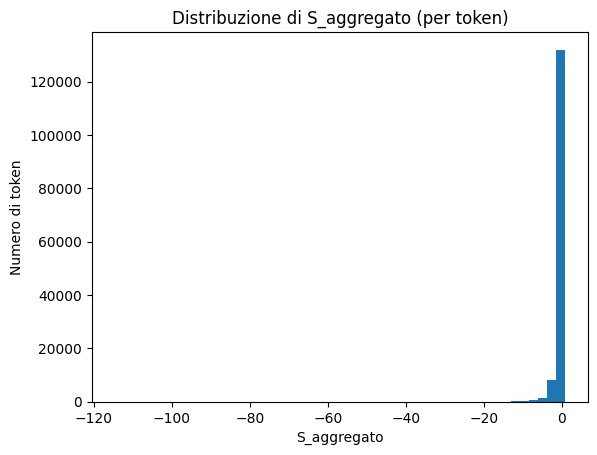

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["S_aggregato"].dropna(), bins=50)
plt.xlabel("S_aggregato")
plt.ylabel("Numero di token")
plt.title("Distribuzione di S_aggregato (per token)")
plt.show()


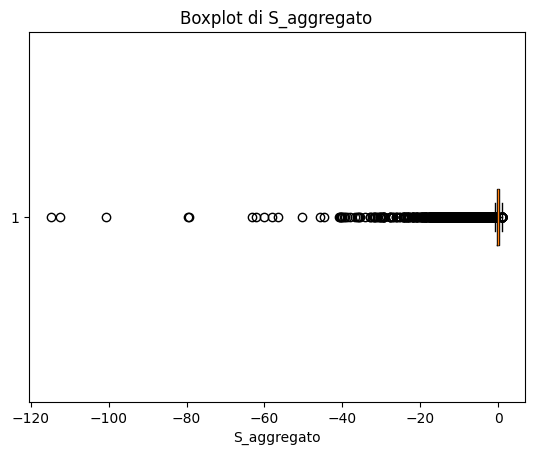

In [42]:
plt.figure()
plt.boxplot(df["S_aggregato"].dropna(), vert=False)
plt.xlabel("S_aggregato")
plt.title("Boxplot di S_aggregato")
plt.show()


In [ ]:
import numpy as np

df["class"] = np.where(
    df["S_aggregato"] > 0, "shrinkage",
    np.where(df["S_aggregato"] < 0, "expansion", "stable")
)

df["class"].value_counts(normalize=True) * 100

# % token che perdono vicini
# % che li guadagnano
# % stabili


class
shrinkage    35.004452
expansion    33.874326
stable       31.121222
Name: proportion, dtype: float64

In [45]:
# espansione forte
df.sort_values("S_aggregato", ascending=True).head(20)

,token,S_aggregato,class
51127,epuro,-114.749489,expansion
23527,boat,-112.367624,expansion
66299,imbonì,-100.777174,expansion
90184,olfatto,-79.637346,expansion
142598,zuppa,-79.270782,expansion
39281,correse,-63.217822,expansion
49736,eleno,-62.077090,expansion
9154,aldo,-60.123052,expansion
138530,varzo,-58.075344,expansion
25371,bucalo,-56.465909,expansion


In [55]:
# shrinkage forte
df.sort_values("S_aggregato", ascending=False).head(200)

,token,S_aggregato,freq_mean
39998,coupon,0.970737,144.375000
65272,http,0.961206,91.222222
31101,cernobbio,0.954183,121.375000
38893,copyright,0.951965,74.750000
77026,lilliput,0.948377,34.571429
...,...,...,...
29003,carrubo,0.850251,14.500000
139095,ventaglio,0.850070,177.700000
61979,gigli,0.849861,58.777778
83495,mignon,0.849738,226.000000


Vedo la correlazione tra shrinkage e frequenza

In [52]:
import pandas as pd
from pathlib import Path

# carica shrinkage
df = pd.read_csv("shrinkage_aggr.csv")

freq_dir = Path(r"../embedding/freq snap")
snapshots = range(1, 11)

# carica tutte le frequenze
freq_dfs = []
for snap in snapshots:
    df_f = pd.read_csv(
        freq_dir / f"vocab_freq_snap{snap}.txt",
        sep=" ",
        names=["token", f"freq_snap{snap}"]
    )
    freq_dfs.append(df_f)

# merge di tutte le frequenze
df_freq = freq_dfs[0]
for d in freq_dfs[1:]:
    df_freq = df_freq.merge(d, on="token", how="outer")

# frequenza media nel tempo
freq_cols = [c for c in df_freq.columns if c.startswith("freq_snap")]
df_freq["freq_mean"] = df_freq[freq_cols].mean(axis=1)

# merge shrinkage + frequenza
df = df.merge(df_freq[["token", "freq_mean"]], on="token", how="left")


In [49]:
from scipy.stats import spearmanr

rho, pval = spearmanr(
    df["freq_mean"],
    df["S_aggregato"],
    nan_policy="omit"
)

rho, pval


(-0.24701446252693315, 0.0)